# Final Project

This notebook combines Project Milestones 1, 2, and 3 in chronological order. The added notes show how the work progresses from initial dataset inspection, to cleaning and first visualizations, to refined charts and dashboard preparation.

## Progress Overview

| Stage | Notebook Section | Contents | Progress Shown |
|---:|---|---|---|
| 1 | Project Milestone 1 | 12 code / 1 markdown cells | Introduces the project focus, loads the 2024 voting dataset, inspects rows and columns, and begins identifying fields that need clearer labels. |
| 2 | Project Milestone 2 | 21 code / 1 markdown cells | Continues cleaning by renaming columns, checking the dataset structure, converting numeric fields, and testing early charts for registered and not registered voters. |
| 3 | Final Project/Project Milestone 3 | 15 code / 9 markdown cells | Builds on the cleaned data with stronger visualizations, age-based participation trends, Gen Z comparisons. |

## Dataframe Note

The combined notebook uses `vote_2024` as the main project dataframe throughout the milestone sections. A small chart-testing dataset from Milestone 2 is named `vote2024_copy` so it does not replace the real voting dataframe. 


# Stage 1: Project Milestone 1

**Source notebook:** `Project Milestone 1 Larry Purnell-1.ipynb`

**Progress shown:** Introduces the project focus, loads the 2024 voting dataset, inspects rows and columns, and begins identifying fields that need clearer labels.

**Milestone progress note:** Milestone 1 establishes the project direction and begins basic dataset inspection. This stage is mostly about understanding what columns are available and what cleaning will be needed.


I have decided to revise my initial milestones with a focus on data cleaning and the identification of key columns that yield the most valuable insights for addressing the relevant research questions.

Upon completion of the data cleaning process, I will determine which columns are essential to retain and which may be discarded in order to effectively analyze the trends influencing the voting behavior of Generation Z, specifically targeting individuals aged 18 to 29. Who in my generation chose not to vote, and which populations made that decision for them by not participating? 

My audience is intended to support political poster creators in their efforts to engage this demographic meaningfully.

Revised Milestones: 

1. Clean the data by removing redundant or unnamed columns that do not contain pertinent data. Rename columns that hold the most importance. 

2. Conduct an analysis to identify the individuals or groups who made decisions on behalf of those who chose not to participate in the 2024 election. 

3. Visualize trends in trends influencing the voting behavior of Generation Z, specifically targeting individuals aged 18 to 29. Who in my generation chose not to vote, and which populations made that decision for them by not participating? 



In [119]:
# This code imports the Python libraries used to clean the data and build the visualizations.
import pandas as pd
import plotly.express as px
import plotly.io as pio
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# This code sets one shared chart style and one shared blue color palette for the notebook.
pio.templates.default = "plotly_white"
BLUE = "#0B4F9C"
LIGHT_BLUE = "#9AD7FF"
WHITE = "#F4F8FA" 
Red = "#c44e52"

COLOR_MAP = {
    "Registered": BLUE,
    "Reg": BLUE,
    "Voted": BLUE,
    "Male": BLUE,
    "MALE": BLUE,
    "Not registered": LIGHT_BLUE,
    "Not Reg": LIGHT_BLUE,
    "Did not vote": LIGHT_BLUE,
    "Female": LIGHT_BLUE,
    "FEMALE": LIGHT_BLUE,
    "No response": WHITE,
    "BOTH SEXES": WHITE
}

In [120]:
# This code loads the 2024 voting CSV file into a dataframe named vote_2024.
vote_2024 = pd.read_csv("vote01_2024_e.csv")

In [121]:
# This code previews the first 10 rows so the dataset can be checked before cleaning.
vote_2024.head(10)

,sex,age,tot_pop,us_cit_tot_pop,us_cit_rep_reg_num,us_cit_rep_reg_pct,us_cit_rep_nr_num,us_cit_rep_nr_pct,us_cit_nr_num,us_cit_nr_pct,us_cit_vote_yes_num,us_cit_vote_yes_pct,us_cit_vote_no_num,us_cit_vote_no_pct,us_cit_vote_nr_num,us_cit_vote_nr_pct,us_tot_rep_reg_pct,us_tot_rep_vote_yes_pct
0,BOTH SEXES,Total 18 years and over,"260,363","236,138","173,854",73.6,"28,009",11.9,"34,275",14.5,"154,308",65.3,"48,480",20.5,"33,351",14.1,66.8,59.3
1,BOTH SEXES,18 to 24 years,"29,986","27,548","16,052",58.3,"5,955",21.6,"5,542",20.1,"13,150",47.7,"9,033",32.8,"5,366",19.5,53.5,43.9
2,BOTH SEXES,25 to 34 years,"44,385","38,963","26,637",68.4,"6,156",15.8,"6,170",15.8,"22,148",56.8,"10,928",28.0,"5,887",15.1,60.0,49.9
3,BOTH SEXES,35 to 44 years,"44,380","38,229","27,920",73.0,"4,859",12.7,"5,450",14.3,"24,340",63.7,"8,555",22.4,"5,334",14.0,62.9,54.8
4,BOTH SEXES,45 to 54 years,"40,089","35,422","27,091",76.5,"3,457",9.8,"4,874",13.8,"24,339",68.7,"6,271",17.7,"4,812",13.6,67.6,60.7
5,BOTH SEXES,55 to 64 years,"41,115","37,982","29,584",77.9,"3,400",9.0,"4,997",13.2,"27,015",71.1,"6,016",15.8,"4,951",13.0,72.0,65.7
6,BOTH SEXES,65 to 74 years,"35,236","33,753","27,161",80.5,"2,504",7.4,"4,088",12.1,"25,389",75.2,"4,352",12.9,"4,011",11.9,77.1,72.1
7,BOTH SEXES,75 years and over,"25,172","24,242","19,410",80.1,"1,677",6.9,"3,155",13.0,"17,928",74.0,"3,325",13.7,"2,989",12.3,77.1,71.2
8,BOTH SEXES,18 years,"4,474","4,258","1,872",44.0,"1,191",28.0,"1,196",28.1,"1,586",37.3,"1,505",35.3,"1,167",27.4,41.8,35.5
9,BOTH SEXES,19 years,"4,062","3,796","2,233",58.8,924,24.3,639,16.8,"1,744",45.9,"1,452",38.2,601,15.8,55.0,42.9


In [122]:
# This code displays the original column names so they can be renamed with clearer labels.
vote_2024.columns

Index(['sex', 'age', 'tot_pop', 'us_cit_tot_pop', 'us_cit_rep_reg_num',
       'us_cit_rep_reg_pct', 'us_cit_rep_nr_num', 'us_cit_rep_nr_pct',
       'us_cit_nr_num', 'us_cit_nr_pct', 'us_cit_vote_yes_num',
       'us_cit_vote_yes_pct', 'us_cit_vote_no_num', 'us_cit_vote_no_pct',
       'us_cit_vote_nr_num', 'us_cit_vote_nr_pct', 'us_tot_rep_reg_pct',
       'us_tot_rep_vote_yes_pct'],
      dtype='object')

In [123]:
# This code renames the Census columns so the dataset is easier to understand in later charts.
vote_2024 = vote_2024.rename(columns={
    "sex": "Sex",
    "age": "Age_Group",
    "tot_pop": "Total_Population",
    "us_cit_tot_pop": "Citizen_Population",
    "us_cit_rep_reg_num": "Registered_Number",
    "us_cit_rep_reg_pct": "Registered_Percent",
    "us_cit_rep_nr_num": "Not_Registered_Number",
    "us_cit_rep_nr_pct": "Not_Registered_Percent",
    "us_cit_nr_num": "No_Response_Registration_Number",
    "us_cit_nr_pct": "No_Response_Registration_Percent",
    "us_cit_vote_yes_num": "Voted_Number",
    "us_cit_vote_yes_pct": "Voted_Percent",
    "us_cit_vote_no_num": "Did_Not_Vote_Number",
    "us_cit_vote_no_pct": "Did_Not_Vote_Percent",
    "us_cit_vote_nr_num": "No_Response_Vote_Number",
    "us_cit_vote_nr_pct": "No_Response_Vote_Percent",
    "us_tot_rep_reg_pct": "Overall_Registration_Percent",
    "us_tot_rep_vote_yes_pct": "Overall_Vote_Percent"
})

In [124]:
# This code previews the renamed dataframe to confirm that the clearer column labels worked.
vote_2024.head(10)

,Sex,Age_Group,Total_Population,Citizen_Population,Registered_Number,Registered_Percent,Not_Registered_Number,Not_Registered_Percent,No_Response_Registration_Number,No_Response_Registration_Percent,Voted_Number,Voted_Percent,Did_Not_Vote_Number,Did_Not_Vote_Percent,No_Response_Vote_Number,No_Response_Vote_Percent,Overall_Registration_Percent,Overall_Vote_Percent
0,BOTH SEXES,Total 18 years and over,"260,363","236,138","173,854",73.6,"28,009",11.9,"34,275",14.5,"154,308",65.3,"48,480",20.5,"33,351",14.1,66.8,59.3
1,BOTH SEXES,18 to 24 years,"29,986","27,548","16,052",58.3,"5,955",21.6,"5,542",20.1,"13,150",47.7,"9,033",32.8,"5,366",19.5,53.5,43.9
2,BOTH SEXES,25 to 34 years,"44,385","38,963","26,637",68.4,"6,156",15.8,"6,170",15.8,"22,148",56.8,"10,928",28.0,"5,887",15.1,60.0,49.9
3,BOTH SEXES,35 to 44 years,"44,380","38,229","27,920",73.0,"4,859",12.7,"5,450",14.3,"24,340",63.7,"8,555",22.4,"5,334",14.0,62.9,54.8
4,BOTH SEXES,45 to 54 years,"40,089","35,422","27,091",76.5,"3,457",9.8,"4,874",13.8,"24,339",68.7,"6,271",17.7,"4,812",13.6,67.6,60.7
5,BOTH SEXES,55 to 64 years,"41,115","37,982","29,584",77.9,"3,400",9.0,"4,997",13.2,"27,015",71.1,"6,016",15.8,"4,951",13.0,72.0,65.7
6,BOTH SEXES,65 to 74 years,"35,236","33,753","27,161",80.5,"2,504",7.4,"4,088",12.1,"25,389",75.2,"4,352",12.9,"4,011",11.9,77.1,72.1
7,BOTH SEXES,75 years and over,"25,172","24,242","19,410",80.1,"1,677",6.9,"3,155",13.0,"17,928",74.0,"3,325",13.7,"2,989",12.3,77.1,71.2
8,BOTH SEXES,18 years,"4,474","4,258","1,872",44.0,"1,191",28.0,"1,196",28.1,"1,586",37.3,"1,505",35.3,"1,167",27.4,41.8,35.5
9,BOTH SEXES,19 years,"4,062","3,796","2,233",58.8,924,24.3,639,16.8,"1,744",45.9,"1,452",38.2,601,15.8,55.0,42.9


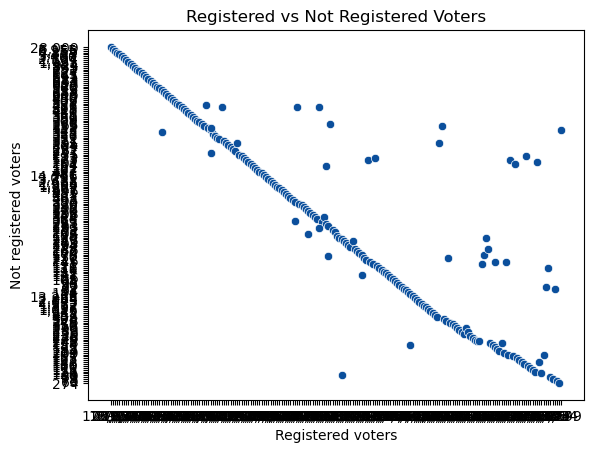

In [125]:
# This code creates an early scatterplot comparing registered and not registered voter counts.
sns.scatterplot(data=vote_2024, x="Registered_Number", y="Not_Registered_Number", color=BLUE)

plt.title("Registered vs Not Registered Voters")
plt.xlabel("Registered voters")
plt.ylabel("Not registered voters")
plt.show()

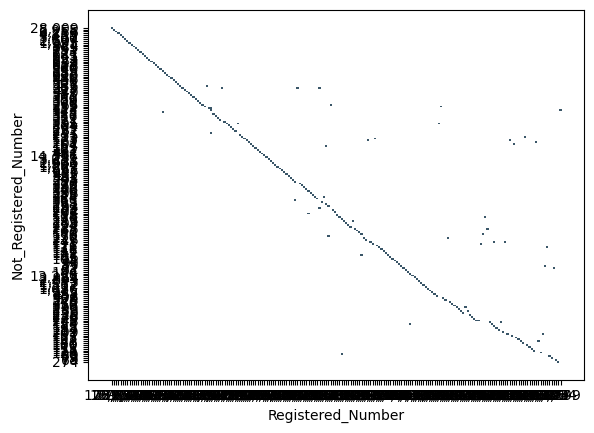

In [126]:
# This code creates an early histogram-style comparison of registered and not registered voters.
sns.histplot(data=vote_2024, x="Registered_Number", y="Not_Registered_Number", color=LIGHT_BLUE)
plt.show()

# Stage 2: Project Milestone 2

**Source notebook:** `Project Milestone 2 Larry Purnell-1.ipynb`

**Progress shown:** Continues cleaning by renaming columns, checking the dataset structure, converting numeric fields, and testing early charts for registered and not registered voters.

**Milestone progress note:** Milestone 2 shows progress from inspection into cleaning and exploratory visualization. The renamed columns make the Census fields easier to understand, and the first charts test ways to compare registration categories.


In [127]:
# This code previews the first rows again before the Milestone 2 cleaning steps.
vote_2024.head(10)

,Sex,Age_Group,Total_Population,Citizen_Population,Registered_Number,Registered_Percent,Not_Registered_Number,Not_Registered_Percent,No_Response_Registration_Number,No_Response_Registration_Percent,Voted_Number,Voted_Percent,Did_Not_Vote_Number,Did_Not_Vote_Percent,No_Response_Vote_Number,No_Response_Vote_Percent,Overall_Registration_Percent,Overall_Vote_Percent
0,BOTH SEXES,Total 18 years and over,"260,363","236,138","173,854",73.6,"28,009",11.9,"34,275",14.5,"154,308",65.3,"48,480",20.5,"33,351",14.1,66.8,59.3
1,BOTH SEXES,18 to 24 years,"29,986","27,548","16,052",58.3,"5,955",21.6,"5,542",20.1,"13,150",47.7,"9,033",32.8,"5,366",19.5,53.5,43.9
2,BOTH SEXES,25 to 34 years,"44,385","38,963","26,637",68.4,"6,156",15.8,"6,170",15.8,"22,148",56.8,"10,928",28.0,"5,887",15.1,60.0,49.9
3,BOTH SEXES,35 to 44 years,"44,380","38,229","27,920",73.0,"4,859",12.7,"5,450",14.3,"24,340",63.7,"8,555",22.4,"5,334",14.0,62.9,54.8
4,BOTH SEXES,45 to 54 years,"40,089","35,422","27,091",76.5,"3,457",9.8,"4,874",13.8,"24,339",68.7,"6,271",17.7,"4,812",13.6,67.6,60.7
5,BOTH SEXES,55 to 64 years,"41,115","37,982","29,584",77.9,"3,400",9.0,"4,997",13.2,"27,015",71.1,"6,016",15.8,"4,951",13.0,72.0,65.7
6,BOTH SEXES,65 to 74 years,"35,236","33,753","27,161",80.5,"2,504",7.4,"4,088",12.1,"25,389",75.2,"4,352",12.9,"4,011",11.9,77.1,72.1
7,BOTH SEXES,75 years and over,"25,172","24,242","19,410",80.1,"1,677",6.9,"3,155",13.0,"17,928",74.0,"3,325",13.7,"2,989",12.3,77.1,71.2
8,BOTH SEXES,18 years,"4,474","4,258","1,872",44.0,"1,191",28.0,"1,196",28.1,"1,586",37.3,"1,505",35.3,"1,167",27.4,41.8,35.5
9,BOTH SEXES,19 years,"4,062","3,796","2,233",58.8,924,24.3,639,16.8,"1,744",45.9,"1,452",38.2,601,15.8,55.0,42.9


In [128]:
# This code removes commas from count columns and converts those columns into numeric values.
vote_2024["Registered_Number"] = (
    vote_2024["Registered_Number"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

vote_2024["Not_Registered_Number"] = (
    vote_2024["Not_Registered_Number"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

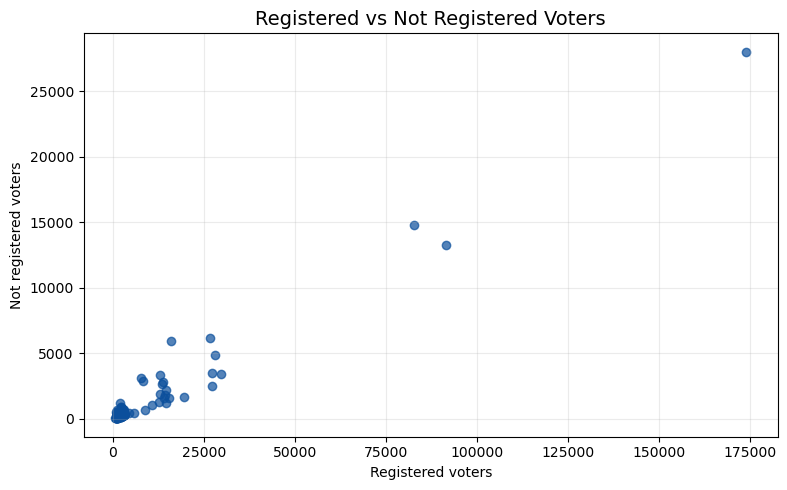

In [129]:
# This code creates a cleaner scatterplot after the registration count columns are converted to numbers.
plt.figure(figsize=(8, 5))
plt.scatter(
    vote_2024["Registered_Number"],
    vote_2024["Not_Registered_Number"],
    color=BLUE,
    alpha=0.7
)

plt.title("Registered vs Not Registered Voters", fontsize=14)
plt.xlabel("Registered voters")
plt.ylabel("Not registered voters")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [130]:
# This code creates a small practice dataset for testing different chart types before using the full voting data.
vote_2024_copy = pd.DataFrame({
    "Status": ["Reg", "Not Reg", "Reg", "Reg", "Not Reg", "Reg"],
    "RawNumbers": [10, 5, 20, 15, 10, 5]
})

In [131]:
# This code creates a practice histogram with the shared blue and light-blue color map.
fig1 = px.histogram(
    vote_2024_copy,
    x="Status",
    y="RawNumbers",
    color="Status",
    title="Registered vs Not Registered",
    color_discrete_map=COLOR_MAP
)
fig1.show()

In [132]:
# This code creates a practice line chart to test change across registration status categories.
fig2 = px.line(
    vote_2024_copy,
    x="Status",
    y="RawNumbers",
    color="Status",
    markers=True,
    title="Registered vs Not Registered",
    color_discrete_map=COLOR_MAP
)
fig2.show()

In [133]:
# This code creates a practice scatterplot using the shared color map.
fig3 = px.scatter(
    vote_2024_copy,
    x="Status",
    y="RawNumbers",
    color="Status",
    title="Registered vs Not Registered",
    color_discrete_map=COLOR_MAP
)
fig3.show()

In [134]:
# This code creates a second practice line chart with markers for easier reading.
fig4 = px.line(
    vote_2024_copy,
    x="Status",
    y="RawNumbers",
    color="Status",
    markers=True,
    title="Registered vs Not Registered",
    color_discrete_map=COLOR_MAP
)
fig4.show()

In [135]:
# This code creates a practice bar chart for comparing registered and not registered counts.
fig5 = px.bar(
    vote_2024_copy,
    x="Status",
    y="RawNumbers",
    color="Status",
    title="Registered vs Not Registered Voters",
    color_discrete_map=COLOR_MAP
)
fig5.show()

In [136]:
# This code creates a practice pie chart to show how registration categories divide a total.
fig6 = px.pie(
    vote_2024_copy,
    names="Status",
    values="RawNumbers",
    title="Registered vs Not Registered Voters",
    color="Status",
    color_discrete_map=COLOR_MAP
)
fig6.update_traces(marker=dict(line=dict(color=BLUE, width=1)))
fig6.show()

# Stage 3: Final Project / Project Milestone 3

Builds on the cleaned data with stronger visualizations, age-based participation trends, Gen Z comparisons. 

### Driving Question Connected To Census

How did Gen Z voters ages 18-29 participate in the 2024 election, and where are the biggest participation gaps?

### Three Data-Connected Questions

1. Which Gen Z ages had the highest and lowest voting percentages in 2024?
2. How many Gen Z citizens voted, did not vote, or gave no voting response?
3. How does the youngest adult group, ages 18-29, compare with the full adult population?

### Data Limitation

This dataset is useful for studying age, sex, registration, voting, non-voting, and non-response. It does not show party choice, candidate choice, race, or income. Because of that, this notebook should focus on participation patterns rather than Republican or Democratic support.


In [137]:
# This code imports the main libraries again for the final project section and resets the shared visual style.
import pandas as pd
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

# This code keeps every final project graph in the same blue, white, and light-blue palette.
pio.templates.default = "plotly_white"
BLUE = "#0B4F9C"
Red = "#F35B43"
WHITE = "#FFFFFF"

COLOR_MAP = {
    "Registered": BLUE,
    "Voted": BLUE,
    "Male": BLUE,
    "MALE": BLUE,
    "18-29 Gen Z": BLUE,
    "Not registered": Red,
    "Did not vote": Red,
    "Female": Red,
    "FEMALE": Red,
    "All adults": Red,
    "No response": WHITE,
    "BOTH SEXES": WHITE
}

In [138]:
# This code loads a fresh copy of the 2024 voting CSV file for the final visualizations.
vote_2024_final = pd.read_csv("vote01_2024_e.csv")

In [139]:
# This code displays the original dataset columns before the final project cleaning steps.
vote_2024_final.keys()

Index(['sex', 'age', 'tot_pop', 'us_cit_tot_pop', 'us_cit_rep_reg_num',
       'us_cit_rep_reg_pct', 'us_cit_rep_nr_num', 'us_cit_rep_nr_pct',
       'us_cit_nr_num', 'us_cit_nr_pct', 'us_cit_vote_yes_num',
       'us_cit_vote_yes_pct', 'us_cit_vote_no_num', 'us_cit_vote_no_pct',
       'us_cit_vote_nr_num', 'us_cit_vote_nr_pct', 'us_tot_rep_reg_pct',
       'us_tot_rep_vote_yes_pct'],
      dtype='object')

In [140]:
# This code makes a working copy of the final project dataframe before renaming and cleaning.
vote_2024_final = vote_2024_final.copy()

In [141]:
# This code renames the columns needed for the final project charts and dashboard.
vote_2024_final = vote_2024_final.rename(columns={
    "sex": "Sex",
    "age": "Age_Group",
    "tot_pop": "Total_Population",
    "us_cit_tot_pop": "Citizen_Population",
    "us_cit_rep_reg_num": "Registered_Number",
    "us_cit_rep_reg_pct": "Registered_Percent",
    "us_cit_rep_nr_num": "Not_Registered_Number",
    "us_cit_rep_nr_pct": "Not_Registered_Percent",
    "us_cit_nr_num": "No_Response_Registration_Number",
    "us_cit_nr_pct": "No_Response_Registration_Percent",
    "us_cit_vote_yes_num": "Voted_Number",
    "us_cit_vote_yes_pct": "Voted_Percent",
    "us_cit_vote_no_num": "Did_Not_Vote_Number",
    "us_cit_vote_no_pct": "Did_Not_Vote_Percent",
    "us_cit_vote_nr_num": "No_Response_Vote_Number",
    "us_cit_vote_nr_pct": "No_Response_Vote_Percent",
    "us_tot_rep_reg_pct": "Overall_Registration_Percent",
    "us_tot_rep_vote_yes_pct": "Overall_Vote_Percent"
})

In [142]:
# This code previews the last 20 rows after the final project columns are renamed.
vote_2024_final.tail(20)

,Sex,Age_Group,Total_Population,Citizen_Population,Registered_Number,Registered_Percent,Not_Registered_Number,Not_Registered_Percent,No_Response_Registration_Number,No_Response_Registration_Percent,Voted_Number,Voted_Percent,Did_Not_Vote_Number,Did_Not_Vote_Percent,No_Response_Vote_Number,No_Response_Vote_Percent,Overall_Registration_Percent,Overall_Vote_Percent
196,FEMALE,62 years,"2,123","1,947","1,560",80.1,148,7.6,239,12.3,"1,446",74.3,245,12.6,255,13.1,73.5,68.1
197,FEMALE,63 years,"2,054","1,905","1,533",80.5,150,7.9,222,11.6,"1,381",72.5,289,15.2,234,12.3,74.6,67.2
198,FEMALE,64 years,"2,247","2,160","1,676",77.6,193,8.9,291,13.5,"1,566",72.5,318,14.7,276,12.8,74.6,69.7
199,FEMALE,65 years,"1,940","1,843","1,472",79.9,100,5.4,270,14.7,"1,388",75.3,187,10.2,267,14.5,75.9,71.6
200,FEMALE,66 years,"1,987","1,900","1,585",83.4,111,5.8,204,10.7,"1,496",78.7,205,10.8,199,10.5,79.8,75.3
201,FEMALE,67 years,"2,048","1,946","1,553",79.8,155,8.0,238,12.2,"1,444",74.2,255,13.1,246,12.7,75.8,70.5
202,FEMALE,68 years,"2,002","1,921","1,530",79.7,124,6.5,266,13.9,"1,432",74.5,224,11.7,265,13.8,76.4,71.5
203,FEMALE,69 years,"2,023","1,931","1,506",78.0,202,10.4,224,11.6,"1,409",73.0,301,15.6,221,11.4,74.4,69.7
204,FEMALE,70 years,"1,853","1,777","1,438",80.9,148,8.3,191,10.7,"1,334",75.1,250,14.1,192,10.8,77.6,72.0
205,FEMALE,71 years,"1,964","1,909","1,512",79.2,128,6.7,269,14.1,"1,427",74.8,235,12.3,246,12.9,77.0,72.7


In [143]:
# This code converts count and percent columns into numbers, creates age fields, and builds reusable analysis tables.

count_columns = [
    "Total_Population", "Citizen_Population", "Registered_Number", "Not_Registered_Number",
    "No_Response_Registration_Number", "Voted_Number", "Did_Not_Vote_Number", "No_Response_Vote_Number"
]

for column in count_columns:
    vote_2024_final[column] = (
        vote_2024_final[column]
        .astype(str)                        # Ensure all values are strings
        .str.replace(",", "", regex=False) # Remove commas (e.g., "1,000" → "1000")
        .pipe(pd.to_numeric, errors="coerce")  # Convert to numeric, invalid values → NaN
    )


# This code converts percent columns to numeric
percent_columns = [
    "Registered_Percent", "Not_Registered_Percent", "No_Response_Registration_Percent",
    "Voted_Percent", "Did_Not_Vote_Percent", "No_Response_Vote_Percent",
    "Overall_Registration_Percent", "Overall_Vote_Percent"
]

for column in percent_columns:
    vote_2024_final[column] = pd.to_numeric(
        vote_2024_final[column],
        errors="coerce"  # Invalid values become NaN instead of causing errors
    )


# This cell Identifys rows that contain exact ages (e.g., "18 years" vs "18 to 24 years")
vote_2024_final["Is_Exact_Age"] = vote_2024_final["Age_Group"].str.match(
    r"^\d+ years$", na=False
)

# This cell creates extract numeric age from the Age_Group column
vote_2024_final["Age_Number"] = pd.to_numeric(
    vote_2024_final["Age_Group"].str.extract(r"^(\d+)")[0],
    errors="coerce"
)


# This cell creates Create Gen Z dataset (ages 18–29)
gen_z_vote2024 = vote_2024_final[
    (vote_2024_final["Sex"] == "BOTH SEXES") &        # Combine genders
    (vote_2024_final["Is_Exact_Age"]) &               # Use exact ages only
    (vote_2024_final["Age_Number"].between(18, 29))   # Filter Gen Z range
].copy()

# This cell cleans and organizes Gen Z data
gen_z_vote2024["Age_Number"] = gen_z_vote2024["Age_Number"].astype(int)  # Convert age to integer
gen_z_vote2024 = gen_z_vote2024.sort_values("Age_Number")               # Sort by age
gen_z_vote2024["Chart_Color"] = "Voted"                                 # Add column for visualization styling


#  Extract overall adult summary (18+)
all_adults = vote_2024_final[
    (vote_2024_final["Sex"] == "BOTH SEXES") &
    (vote_2024_final["Age_Group"] == "Total 18 years and over")
].iloc[0]  # Select the single summary row


# Define and filter broad age groups
broad_age_order = [
    "18 to 24 years", "25 to 34 years", "35 to 44 years",
    "45 to 54 years", "55 to 64 years", "65 to 74 years",
    "75 years and over"
]

broad_age_groups = vote_2024_final[
    (vote_2024_final["Sex"] == "BOTH SEXES") &
    (vote_2024_final["Age_Group"].isin(broad_age_order))
].copy()


# 7. Create Gen Z summary table for visualization
gen_z_summary = pd.DataFrame({
    "Voting_Status": ["Voted", "Did not vote", "No response"],
    "People_Thousands": [
        gen_z_vote2024["Voted_Number"].sum(),
        gen_z_vote2024["Did_Not_Vote_Number"].sum(),
        gen_z_vote2024["No_Response_Vote_Number"].sum()
    ]
})

# 8. Display result
gen_z_summary

all_adults = vote_2024_final[
    (vote_2024_final["Sex"] == "BOTH SEXES")
    & (vote_2024_final["Age_Group"] == "Total 18 years and over")
].iloc[0]

broad_age_order = [
    "18 to 24 years", "25 to 34 years", "35 to 44 years", "45 to 54 years",
    "55 to 64 years", "65 to 74 years", "75 years and over"
]

broad_age_groups = vote_2024_final[
    (vote_2024_final["Sex"] == "BOTH SEXES")
    & (vote_2024_final["Age_Group"].isin(broad_age_order))
].copy()

gen_z_summary = pd.DataFrame({
    "Voting_Status": ["Voted", "Did not vote", "No response"],
    "People_Thousands": [
        gen_z_vote2024["Voted_Number"].sum(),
        gen_z_vote2024["Did_Not_Vote_Number"].sum(),
        gen_z_vote2024["No_Response_Vote_Number"].sum()
    ]
})

gen_z_summary

,Voting_Status,People_Thousands
0,Voted,23537
1,Did not vote,14479
2,No response,8366


In [144]:
# This code previews the cleaned Gen Z dataframe that will be used in the final charts.
gen_z_vote2024.head(10)

,Sex,Age_Group,Total_Population,Citizen_Population,Registered_Number,Registered_Percent,Not_Registered_Number,Not_Registered_Percent,No_Response_Registration_Number,No_Response_Registration_Percent,...,Voted_Percent,Did_Not_Vote_Number,Did_Not_Vote_Percent,No_Response_Vote_Number,No_Response_Vote_Percent,Overall_Registration_Percent,Overall_Vote_Percent,Is_Exact_Age,Age_Number,Chart_Color
8,BOTH SEXES,18 years,4474,4258,1872,44.0,1191,28.0,1196,28.1,...,37.3,1505,35.3,1167,27.4,41.8,35.5,True,18,Voted
9,BOTH SEXES,19 years,4062,3796,2233,58.8,924,24.3,639,16.8,...,45.9,1452,38.2,601,15.8,55.0,42.9,True,19,Voted
10,BOTH SEXES,20 years,4100,3733,2116,56.7,883,23.7,733,19.6,...,44.6,1370,36.7,699,18.7,51.6,40.6,True,20,Voted
11,BOTH SEXES,21 years,4256,4014,2318,57.7,791,19.7,906,22.6,...,47.0,1299,32.4,829,20.6,54.5,44.3,True,21,Voted
12,BOTH SEXES,22 years,4286,3865,2440,63.1,753,19.5,672,17.4,...,53.1,1126,29.1,685,17.7,56.9,47.9,True,22,Voted
13,BOTH SEXES,23 years,3952,3555,2323,65.3,627,17.6,606,17.0,...,54.5,1000,28.1,617,17.3,58.8,49.1,True,23,Voted
14,BOTH SEXES,24 years,4857,4326,2751,63.6,785,18.1,790,18.3,...,52.6,1282,29.6,769,17.8,56.6,46.9,True,24,Voted
15,BOTH SEXES,25 years,4029,3604,2316,64.3,641,17.8,648,18.0,...,51.4,1110,30.8,642,17.8,57.5,46.0,True,25,Voted
16,BOTH SEXES,26 years,4450,3881,2598,66.9,532,13.7,751,19.3,...,57.4,936,24.1,718,18.5,58.4,50.0,True,26,Voted
17,BOTH SEXES,27 years,4220,3718,2411,64.9,683,18.4,623,16.8,...,52.7,1134,30.5,626,16.8,57.1,46.4,True,27,Voted


### Visualization 1: Gen Z Voting Percent by Age

This bar chart answers Question 1. It shows which exact Gen Z ages had higher or lower voting percentages.


In [145]:
# This code creates a line chart showing how Gen Z voting turnout changes by exact age.
fig1 = px.line(
    gen_z_vote2024,
    x="Age_Number",
    y="Voted_Percent",
    color="Chart_Color",
    markers=True,
    title="Gen Z Voting Turnout by Age (2024)",
    labels={
        "Age_Number": "Age",
        "Voted_Percent": "Voter turnout (%)",
        "Chart_Color": "Measure"
    },
    color_discrete_map=COLOR_MAP
)

fig1.update_traces(
    line=dict(color=BLUE, width=3),
    marker=dict(color=Red, size=8, line=dict(color=BLUE, width=1)),
    text=gen_z_vote2024["Voted_Percent"],
    texttemplate="%{text:.1f}%",
    textposition="top center"
)

fig1.update_layout(
    xaxis=dict(dtick=1),
    yaxis=dict(ticksuffix="%", range=[0, 70]),
    showlegend=True
)
fig1.show()

In [146]:
fig3 = px.scatter(
    vote_2024_final,
    x="Registered_Number",
    y="Voted_Number",
    title="Registered vs Actual Voters",
    labels={
        "Registered_Number": "Registered Voters",
        "Voted_Number": "People Who Voted"
    }
)

fig3.update_traces(marker=dict(color="#c44e52", size=8))
fig3.show()

### Visualization 2: 

In [147]:
# This code creates a bar chart showing the voting percent for each exact Gen Z age.
fig2 = px.bar(
    gen_z_vote2024,
    x="Age_Number",
    y="Voted_Percent",
    color="Chart_Color",
    text="Voted_Percent",
    title="Gen Z Voting Percent by Age, 2024",
    labels={
        "Age_Number": "Age",
        "Voted_Percent": "Voted percent",
        "Chart_Color": "Measure"
    },
    color_discrete_map=COLOR_MAP
)

fig2.update_traces(
    marker_color=Red,
    marker_line_color=Red,
    marker_line_width=1,
    texttemplate="%{text:.1f}%",
    textposition="outside"
)
fig2.update_layout(
    xaxis=dict(dtick=1),
    yaxis=dict(ticksuffix="%", range=[0, 70]),
    showlegend=True
)
fig2.show()

### Visualization 3: Gen Z Voting Status Pie Chart

This pie chart answers Question 2. It combines ages 18-29 and shows how the Gen Z citizen population was divided between voted, did not vote, and no response.


In [148]:
# This code creates a pie chart showing Gen Z voting status in three groups.
gen_z_vote_pie = pd.DataFrame({
    "Voting_Status": ["Voted", "Did not vote", "No response"],
    "People_Thousands": [
        gen_z_vote2024["Voted_Number"].sum(),
        gen_z_vote2024["Did_Not_Vote_Number"].sum(),
        gen_z_vote2024["No_Response_Vote_Number"].sum()
    ]
})

fig3 = px.pie(
    gen_z_vote_pie,
    names="Voting_Status",
    values="People_Thousands",
    title="Gen Z Voting Status, Ages 18-29",
    hole=.3,
    color="Voting_Status",
    color_discrete_map=COLOR_MAP
)

fig3.update_traces(
    textinfo="percent+label",
    marker=dict(line=dict(color=BLUE, width=1))
)
fig3.show()

### Visualization 4: All Adults Voting Status Pie Chart

This pie chart answers Question 3 by giving a full adult comparison point. It shows the voting status for everyone 18 years and older in the dataset.


In [149]:
# This code creates a pie chart showing voting status for all adults 18 and older.
all_adults_vote_pie = pd.DataFrame({
    "Voting_Status": ["Voted", "Did not vote", "No response"],
    "People_Thousands": [
        all_adults["Voted_Number"],
        all_adults["Did_Not_Vote_Number"],
        all_adults["No_Response_Vote_Number"]
    ]
})

fig4 = px.pie(
    all_adults_vote_pie,
    names="Voting_Status",
    values="People_Thousands",
    title="Voting Status for All Adults 18 and Older",
    color="Voting_Status",
    hole=.3,
    color_discrete_map=COLOR_MAP
)

fig4.update_traces(
    textinfo="percent+label",
    marker=dict(line=dict(color=BLUE, width=1))
)
fig4.show()

In [150]:
# This code creates a grouped bar chart comparing voting status shares across broad age groups.
broad_age_groups["Age_Group"] = pd.Categorical(
    broad_age_groups["Age_Group"],
    categories=broad_age_order,
    ordered=True
)
broad_age_status = broad_age_groups.sort_values("Age_Group")

broad_age_long = broad_age_status.melt(
    id_vars=["Age_Group"],
    value_vars=["Voted_Percent", "Did_Not_Vote_Percent", "No_Response_Vote_Percent"],
    var_name="Voting_Status",
    value_name="Percent"
)

broad_age_long["Voting_Status"] = broad_age_long["Voting_Status"].map({
    "Voted_Percent": "Voted",
    "Did_Not_Vote_Percent": "Did not vote",
    "No_Response_Vote_Percent": "No response"
})

fig_broad_status = px.bar(
    broad_age_long,
    x="Age_Group",
    y="Percent",
    color="Voting_Status",
    title="Voting Status Share by Age Group",
    labels={
        "Age_Group": "Age group",
        "Percent": "Percent of citizen population",
        "Voting_Status": "Voting status"
    },
    color_discrete_map=COLOR_MAP
)
fig_broad_status.update_traces(marker_line_color=BLUE, marker_line_width=1)
fig_broad_status.update_layout(yaxis_ticksuffix="%", xaxis_tickangle=-25)
fig_broad_status.show()

In [159]:
# Line chart: male vs female voting rates by age group

sex_colors = {
      "Female": Red,
    "Male": BLUE
}

age_order = [
    "18 to 24 years", "25 to 34 years", "35 to 44 years",
    "45 to 54 years", "55 to 64 years", "65 to 74 years",
    "75 years and over"
]

gender_age = vote_2024[
    (vote_2024["Sex"].isin(["FEMALE", "MALE"])) &
    (vote_2024["Age_Group"].isin(age_order))
].copy()

gender_age["Age_Group"] = pd.Categorical(
    gender_age["Age_Group"],
    categories=age_order,
    ordered=True
)

gender_age["Voted_Percent"] = pd.to_numeric(gender_age["Voted_Percent"], errors="coerce")
gender_age = gender_age.sort_values("Age_Group")

fig_gender_line = px.line(
    gender_age,
    x="Age_Group",
    y="Voted_Percent",
    color="Sex",
    markers=True,
    title="Male vs Female Voting Rates by Age Group",
    labels={
        "Age_Group": "Age group",
        "Voted_Percent": "Voting rate",
        "Sex": "Sex"
    },
    color_discrete_map=sex_colors
)

fig_gender_line.update_traces(line=dict(width=3), marker=dict(size=9))
fig_gender_line.update_layout(
    title_x=0.02,
    yaxis_ticksuffix="%",
    xaxis_tickangle=-25,
    hovermode="x unified"
)

fig_gender_line.show()


In [152]:
# This code creates a data frame comparing Age Number and Gender. 
gen_z_by_gender = vote_2024_final[
    (vote_2024_final["Sex"].isin(["FEMALE", "MALE"])) &
    (vote_2024_final["Is_Exact_Age"]) &
    (vote_2024_final["Age_Number"].between(18, 29))
].copy()

gen_z_by_gender["Age_Number"] = gen_z_by_gender["Age_Number"].astype(int)

gen_z_by_gender["Gender"] = gen_z_by_gender["Sex"].str.title()

gen_z_by_gender = gen_z_by_gender.sort_values(
    ["Age_Number", "Gender"]
)

gen_z_by_gender.head()

,Sex,Age_Group,Total_Population,Citizen_Population,Registered_Number,Registered_Percent,Not_Registered_Number,Not_Registered_Percent,No_Response_Registration_Number,No_Response_Registration_Percent,...,Voted_Percent,Did_Not_Vote_Number,Did_Not_Vote_Percent,No_Response_Vote_Number,No_Response_Vote_Percent,Overall_Registration_Percent,Overall_Vote_Percent,Is_Exact_Age,Age_Number,Gender
152,FEMALE,18 years,2133,2018,885,43.9,545,27.0,587,29.1,...,37.0,701,34.7,570,28.3,41.5,35.0,True,18,Female
80,MALE,18 years,2341,2241,987,44.0,646,28.8,608,27.1,...,37.5,804,35.9,597,26.6,42.1,35.9,True,18,Male
153,FEMALE,19 years,2076,1937,1186,61.2,437,22.6,314,16.2,...,51.6,649,33.5,289,14.9,57.1,48.1,True,19,Female
81,MALE,19 years,1987,1859,1047,56.3,487,26.2,325,17.5,...,40.1,803,43.2,312,16.8,52.7,37.5,True,19,Male
154,FEMALE,20 years,1951,1776,1050,59.2,452,25.5,273,15.4,...,50.7,616,34.7,259,14.6,53.8,46.2,True,20,Female


In [153]:
# This code creates a line chart showing the share of Gen Z voters by gender
fig_gender_line = px.line(
    gen_z_by_gender,
    x="Age_Number",
    y="Voted_Percent",
    color="Gender",
    markers=True,
    title="Gen Z Male vs Female Voting Rates by Age",
    labels={
        "Age_Number": "Age",
        "Voted_Percent": "Voting Rate (%)",
        "Gender": "Gender"
    },
    color_discrete_map={
        "Female": "#D84A4A",
        "Male": "#0B4F9C"
    }
)

fig_gender_line.update_traces(
    line=dict(width=3),
    marker=dict(size=8),
    hovertemplate=
    "<b>Age:</b> %{x}<br>" +
    "<b>Voting Rate:</b> %{y:.1f}%<br>" +
    "<b>Gender:</b> %{fullData.name}<extra></extra>"
)

fig_gender_line.update_layout(
    template="plotly_white",
    title_x=0.5,
    yaxis_ticksuffix="%",
    yaxis_range=[0, 75],
    xaxis=dict(dtick=1),
    hovermode="x unified",
    legend_title="Gender",
    font=dict(size=14)
)

fig_gender_line.show()

In [154]:
# Create a pie chart showing the share of Gen Z voters by gender
fig_gender_pie = px.pie(
    gen_z_by_gender,
    names="Gender",
    values="Voted_Number",
    title="Gen Z Voters by Gender",
    hole=0.4,
    color="Gender",
    color_discrete_map={
        "Female": "#D84A4A",
        "Male": "#0B4F9C"
    }
)

fig_gender_pie.update_traces(
    textinfo="label+percent",
    hovertemplate=
    "<b>Gender:</b> %{label}<br>" +
    "Voters: %{value:,.0f}<br>" +
    "Share: %{percent}<extra></extra>"
)

fig_gender_pie.update_layout(
    template="plotly_white",
    title_x=0.5,
    legend_title="Gender",
    font=dict(size=14)
)

fig_gender_pie.show()

## Gen Z Dashboard App

This section connects the notebook analysis to the Dash dashboard in `dashboard_app.py`. The dashboard focuses on Gen Z voters ages 18-29 and places the main percentages above the charts so the viewer sees the key findings first.

In [155]:
# This code creates the same Gen Z percentage summary shown above the dashboard charts.
from IPython.display import HTML, display

# Use the cleaned Gen Z dataframe from the project charts.
gen_z_dashboard = gen_z_vote2024.copy()

gen_z_total_citizens = gen_z_dashboard["Citizen_Population"].sum()
gen_z_registered = gen_z_dashboard["Registered_Number"].sum()
gen_z_voted = gen_z_dashboard["Voted_Number"].sum()
gen_z_did_not_vote = gen_z_dashboard["Did_Not_Vote_Number"].sum()
gen_z_no_response = gen_z_dashboard["No_Response_Vote_Number"].sum()

dashboard_percentages = pd.DataFrame({
    "Dashboard_Metric": ["Registered", "Voted", "Did not vote", "No response"],
    "Percent": [
        gen_z_registered / gen_z_total_citizens * 100,
        gen_z_voted / gen_z_total_citizens * 100,
        gen_z_did_not_vote / gen_z_total_citizens * 100,
        gen_z_no_response / gen_z_total_citizens * 100
    ],
    "People_Thousands": [
        gen_z_registered,
        gen_z_voted,
        gen_z_did_not_vote,
        gen_z_no_response
    ]
})

cards_html = "".join(
    f"""
    <div style='background:white;border:1px solid #DDE5EF;border-top:5px solid {color};border-radius:8px;padding:14px;'>
        <div style='font-size:12px;font-weight:700;color:#4B5563;text-transform:uppercase;'>{metric}</div>
        <div style='font-size:30px;font-weight:800;color:{color};margin-top:6px;'>{percent:.1f}%</div>
        <div style='font-size:12px;color:#6B7280;margin-top:4px;'>{people:,.0f} thousand people</div>
    </div>
    """
    for metric, percent, people, color in zip(
        dashboard_percentages["Dashboard_Metric"],
        dashboard_percentages["Percent"],
        dashboard_percentages["People_Thousands"],
        ["#0B4F9C", "#0B4F9C", "#D84A4A", "#8A8F98"]
    )
)

display(HTML(f"<div style='display:grid;grid-template-columns:repeat(4,1fr);gap:12px;margin:16px 0;'>{cards_html}</div>"))
dashboard_percentages

,Dashboard_Metric,Percent,People_Thousands
0,Registered,61.718918,28624
1,Voted,50.750356,23537
2,Did not vote,31.219544,14479
3,No response,18.038725,8366


In [156]:
# This code shows how to run the Dash dashboard app from this project folder.
from pathlib import Path

project_folder = Path("/Users/ljpurnell/Desktop/indata_sp26")
dashboard_file = project_folder / "dashboard_app.py"

print(f"Dashboard app file: {dashboard_file}")
print("Run this in Terminal:")
print(f"cd {project_folder}")
print("python dashboard_app.py")
print("Then open: http://127.0.0.1:8050")

Dashboard app file: /Users/ljpurnell/Desktop/indata_sp26/dashboard_app.py
Run this in Terminal:
cd /Users/ljpurnell/Desktop/indata_sp26
python dashboard_app.py
Then open: http://127.0.0.1:8050


In [157]:
# This code embeds the local dashboard in the notebook when the Dash server is running.
from IPython.display import IFrame

IFrame("http://127.0.0.1:8050", width="100%", height=900)